# BioCRNPyler-AutoReduce Interface

The goal of this notebook is to demonstrate how to use BioCRNpyler models with AutoReduce, which is pretty simple: load the saved SBML file into AutoReduce!

In this example, we build a simple GFP expression model with BioCRNpyler and load it into AutoReduce to perform model reduction and explore various reduced models. Note that BioCRNpyler is an optional dependency for AutoReduce, you can install the package with the bio tag: `autoreduce[bio]` to get it or simply install biocrnpyler in your environment: `pip install biocrnpyler`.


## Pipeline workflow

This pipeline consists of five steps: (1) mechanisticmodeling, (2) SBML import, (3) reduction, (4) validation, and (5) model export.

1. The detailed CRN is generated from components and mechanisms. This keeps the mechanistic assumptions explicit. Here, transcription and translation mechanisms introduce two reversible binding reactions, two production reactions, and degradation reactions for transcript and protein.
2. The full model is loaded into AutoReduce with a specified output. The choice of output matters because a reduced model that preserves one species may not preserve all species. Here, the selected output is the GFP protein species, `protein_GFP`.
3. Conservation laws are applied when the model contains conserved totals. This reduction is algebraic and exact for the reaction network under the included reactions. Here, we have DNA, RNAP, and ribosome species, that are conserved because free and bound forms sum to fixed totals when the resource machinery is not produced or degraded.
4. Time-scale separation is applied to remove intermediate complexes (assuming certain reactions occur much faster than others). 
5. The reduced model is exported so it can be reused in the same modeling workflow as the full model, while retaining a record of the reduction assumptions used to obtain it.


### Package imports and setup 

In [22]:
import warnings

import numpy as np
from sympy import Symbol

try:
    import biocrnpyler as bcp
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "BioCRNpyler is required for this notebook. Install with "
        "`pip install autoreduce[bio]`."
    ) from exc

from autoreduce import (
    load_sbml,
    solve_conservation_laws,
    solve_ode,
    solve_sensitivity,
    solve_timescale_separation,
)


### Set initial conditions

In [23]:
TOTAL_DNA = 0.01
TOTAL_RNAP = 10
TOTAL_RIBOSOME = 20
TOTAL_RNAASE = 2.0

initial_conditions = {
    "dna_gfp": TOTAL_DNA,
    "protein_RNAP": TOTAL_RNAP,
    "protein_Ribo": TOTAL_RIBOSOME,
    "protein_RNase": TOTAL_RNAASE,
}


## Build CRN using BioCRNpyler

We use the BioCRNpyler component `DNAassembly` as the main part in the system. We initialize this component in a mechanistic transcription-translation extract mixture. This mixture instantiates the resources needed for protein expression: RNAP and ribosomes. The transcription reaction produces the mRNA species and the translation of the mRNA to the final protein is included via complex formation. BioCRNpyler automatically generates the species, reactions, and parameters for this system from the high-level specification.


In [24]:
gfp_dna = bcp.DNAassembly(
    name="gfp",
    promoter="pconst",
    rbs="rbs_strong",
    protein="GFP",
)

degradation = bcp.Dilution(
    mechanism_type="global_mechanism",
    filter_dict = {"GFP": True},
    default_on = False
)


txtl_extract = bcp.TxTlExtract(
    name="txtl",
    components=[gfp_dna],
    parameter_file="default_parameters.txt",
    initial_condition_dictionary=initial_conditions,
    global_mechanisms=[degradation]
)

gfp_crn = txtl_extract.compile_crn()

gfp_crn.write_sbml_file("models/biocrnpyler_gfp_expression.xml")

# print the model particulars
print(f"Species: {len(gfp_crn.species)}")
for species in gfp_crn.species:
    print(f"  {repr(species)}")

print(f"\nReactions: {len(gfp_crn.reactions)}")
for reaction in gfp_crn.reactions:
    print(f"  {reaction}")


Species: 9
  dna_gfp
  protein_RNAP
  rna_gfp
  complex_dna_gfp_protein_RNAP_
  protein_Ribo
  protein_GFP
  complex_protein_Ribo_rna_gfp_
  protein_RNase
  complex_protein_RNase_rna_gfp_

Reactions: 7
  dna[gfp]+protein[RNAP] <--> complex[dna[gfp]:protein[RNAP]]
  complex[dna[gfp]:protein[RNAP]] --> dna[gfp]+rna[gfp]+protein[RNAP]
  rna[gfp]+protein[Ribo] <--> complex[protein[Ribo]:rna[gfp]]
  complex[protein[Ribo]:rna[gfp]] --> rna[gfp]+protein[GFP]+protein[Ribo]
  protein[GFP] --> 
  rna[gfp]+protein[RNase] <--> complex[protein[RNase]:rna[gfp]]
  complex[protein[RNase]:rna[gfp]] --> protein[RNase]


c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\biocrnpyler\core\parameter.py:1575: UserWarning: parameter file contains no unit column! Please add a column named ['unit', 'units'].
  warn(


## AutoReduce: `load_sbml` to load the BioCRNpyler model

When loading the model, we select `protein_GFP` as the output to preserve. The initial conditions will be set after import so the AutoReduce `System` object uses the same DNA and machinery totals as the BioCRNpyler model.


In [25]:
initial_conditions

{'dna_gfp': 0.01, 'protein_RNAP': 10, 'protein_Ribo': 20, 'protein_RNase': 2.0}

In [26]:
full_system = load_sbml("models/biocrnpyler_gfp_expression.xml",
                   outputs=["protein_GFP"])

# set the initial conditions for the system
species_to_index = {
    str(state): index for index, state in enumerate(full_system.x)
}

for species_name, concentration in initial_conditions.items():
    if species_name in species_to_index:
        full_system.x_init[species_to_index[species_name]] = concentration

Your output 'protein_GFP' is now set using the system.C matrix!


### Print the `System` attributes

In [27]:
print("States and initial conditions")
for index, state in enumerate(full_system.x):
    print(f"  {index}: {state} = {full_system.x_init[index]}")

print("\nParameters")
for parameter, value in zip(full_system.params, full_system.params_values):
    print(f"  {parameter} = {value}")


States and initial conditions
  0: dna_gfp = 0.01
  1: protein_RNAP = 10
  2: rna_gfp = 0.0
  3: complex_dna_gfp_protein_RNAP_ = 0.0
  4: protein_Ribo = 20
  5: protein_GFP = 0.0
  6: complex_protein_Ribo_rna_gfp_ = 0.0
  7: protein_RNase = 2.0
  8: complex_protein_RNase_rna_gfp_ = 0.0

Parameters
  kb__ = 100.0
  ku__ = 10.0
  ktx__ = 0.05
  ktl__ = 0.05
  kdil__ = 0.001
  kdeg__rna_degradation_mm = 0.01


### Use the `solvers` module for simulation 

Full model simulation


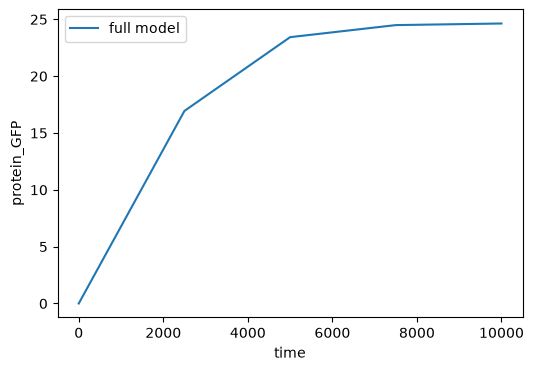

In [28]:
timepoints = np.linspace(0, 10000, 5)
full_solution = solve_ode(full_system, timepoints)
full_gfp_index = full_system.x.index(Symbol("protein_GFP"))
full_gfp = full_solution[:, full_gfp_index]

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(timepoints, full_gfp, label="full model")
    ax.set_xlabel("time")
    ax.set_ylabel("protein_GFP")
    ax.legend()
except ModuleNotFoundError:
    print("matplotlib is not installed; skipping plot.")


### Reduction step 1: Apply conservation laws

We have four conserved quantities: (1) DNA, (2) RNAP, (3) ribosome, and (4) RNAase. Applying these laws removes free DNA, free RNAP, free ribosome, and free RNAase from the full system and introduces total quantities as parameters.


In [29]:
state = {str(symbol): symbol for symbol in full_system.x}

conserved_sets = [
    [
        state["dna_gfp"],
        state["complex_dna_gfp_protein_RNAP_"],
    ],
    [
        state["protein_RNAP"],
        state["complex_dna_gfp_protein_RNAP_"],
    ],
    [
        state["protein_Ribo"],
        state["complex_protein_Ribo_rna_gfp_"],
    ],
    [
        state["protein_RNase"],
        state["complex_protein_RNase_rna_gfp_"],
    ]
]

total_quantities = {
    "DNA_total": TOTAL_DNA,
    "RNAP_total": TOTAL_RNAP,
    "Ribo_total": TOTAL_RIBOSOME,
    "RNAase_total": TOTAL_RNAASE,
}

states_to_eliminate = [
    state["dna_gfp"],
    state["protein_RNAP"],
    state["protein_Ribo"],
    state["protein_RNase"]
]

conserved_system = solve_conservation_laws(
    full_system,
    conserved_sets=conserved_sets,
    total_quantities=total_quantities,
    states_to_eliminate=states_to_eliminate,
)

print("States after conservation law reduction")
for index, state_symbol in enumerate(conserved_system.x):
    print(f"  {index}: {state_symbol}")


States after conservation law reduction
  0: rna_gfp
  1: complex_dna_gfp_protein_RNAP_
  2: protein_GFP
  3: complex_protein_Ribo_rna_gfp_
  4: complex_protein_RNase_rna_gfp_


### Print model equations at this stage:

In [30]:
conserved_system.f

[complex_dna_gfp_protein_RNAP_*ktx__ + complex_protein_RNase_rna_gfp_*ku__ + complex_protein_Ribo_rna_gfp_*ktl__ + complex_protein_Ribo_rna_gfp_*ku__ - kb__*rna_gfp*(RNAase_total - complex_protein_RNase_rna_gfp_) - kb__*rna_gfp*(Ribo_total - complex_protein_Ribo_rna_gfp_),
 -complex_dna_gfp_protein_RNAP_*ktx__ - complex_dna_gfp_protein_RNAP_*ku__ + kb__*(DNA_total - complex_dna_gfp_protein_RNAP_)*(RNAP_total - complex_dna_gfp_protein_RNAP_),
 complex_protein_Ribo_rna_gfp_*ktl__ - kdil__*protein_GFP,
 -complex_protein_Ribo_rna_gfp_*ktl__ - complex_protein_Ribo_rna_gfp_*ku__ + kb__*rna_gfp*(Ribo_total - complex_protein_Ribo_rna_gfp_),
 -complex_protein_RNase_rna_gfp_*kdeg__rna_degradation_mm - complex_protein_RNase_rna_gfp_*ku__ + kb__*rna_gfp*(RNAase_total - complex_protein_RNase_rna_gfp_)]

### Reduction step 2: Apply time-scale separation

Assume that complex formation is a fast process relative to the other steps. This collapses the model to mRNA and GFP protein dynamics. AutoReduce can obtain the reduced model by applying such a time-scale separation assumption. 

In [31]:
state = {str(symbol): symbol for symbol in conserved_system.x}

slow_states = [state["rna_gfp"], state["protein_GFP"]]

reduced_system, fast_subsystem = solve_timescale_separation(
    conserved_system,
    slow_states=slow_states
)

print("Reduced states")
for state_symbol in reduced_system.x:
    print(f"  {state_symbol}")

print("\nReduced dynamics")
for state_symbol, ode in zip(reduced_system.x, reduced_system.f):
    print(f"  d{state_symbol}/dt = {ode}")


Successful solution obtained with states: [rna_gfp, protein_GFP]!
Reduced states
  rna_gfp
  protein_GFP

Reduced dynamics
  drna_gfp/dt = (-RNAase_total*kb__**2*kdeg__rna_degradation_mm*rna_gfp + ktx__*(kb__*rna_gfp + kdeg__rna_degradation_mm + ku__)*(DNA_total*kb__ + RNAP_total*kb__ + ktx__ + ku__ - sqrt(DNA_total**2*kb__**2 - 2*DNA_total*RNAP_total*kb__**2 + 2*DNA_total*kb__*ktx__ + 2*DNA_total*kb__*ku__ + RNAP_total**2*kb__**2 + 2*RNAP_total*kb__*ktx__ + 2*RNAP_total*kb__*ku__ + ktx__**2 + 2*ktx__*ku__ + ku__**2))/2)/(kb__*(kb__*rna_gfp + kdeg__rna_degradation_mm + ku__))
  dprotein_GFP/dt = (Ribo_total*kb__*ktl__*rna_gfp - kdil__*protein_GFP*(kb__*rna_gfp + ktl__ + ku__))/(kb__*rna_gfp + ktl__ + ku__)


## Compare: Error and robustness 

AutoReduce provides methods to compare the performance of the full model vs the reduced model in terms of the accuracy of the output (error) and the robustness of the reduced model to perturbations in the parameters. This is achieved by computing the numerical metrics as shown below.

Output error over time horizon: 5.78


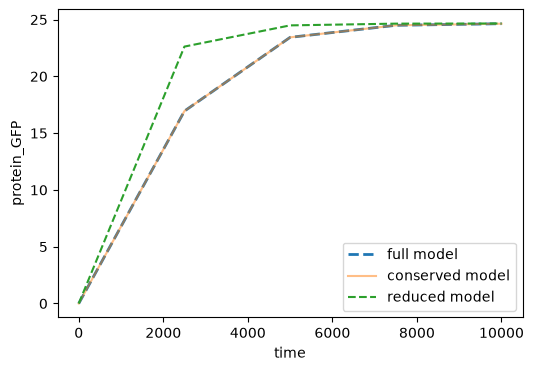

In [32]:
from autoreduce import get_error_metric

conserved_gfp = solve_ode(conserved_system, timepoints)
output_conserved_gfp = conserved_gfp[:, conserved_system.x.index(Symbol("protein_GFP"))]
reduced_gfp = solve_ode(reduced_system, timepoints)
output_reduced_gfp = reduced_gfp[:, reduced_system.x.index(Symbol("protein_GFP"))]

error = get_error_metric(full_system, reduced_system, timepoints)

print(f"Output error over time horizon: {error:.3g}")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(timepoints, full_gfp, label="full model", ls='--', lw=2)
    ax.plot(timepoints, output_conserved_gfp, label="conserved model", alpha=0.5)
    ax.plot(timepoints, output_reduced_gfp, "--", label="reduced model")
    ax.set_xlabel("time")
    ax.set_ylabel("protein_GFP")
    ax.legend()
except ModuleNotFoundError:
    print("matplotlib is not installed; skipping plot.")


Removing all complex formation steps led to some inaccuracies! 

### Robustness computation


In [33]:
from autoreduce import get_robustness_metric

# resolution for robustness analysis
# timepoints kept low for quick tests
sensitivity_timepoints = np.linspace(0, 5000, 5)
robustness_metric = get_robustness_metric(
    full_system,
    reduced_system,
    timepoints_ode=sensitivity_timepoints,
    timepoints_ssm=sensitivity_timepoints,
)


C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\ssm.py:239: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(sens_func_ode, S0, timepoints, tfirst=True)


SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete


c:\Users\ayush\anaconda3\envs\autoreduce\Lib\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


The robustness metric contains a tuple `(Se, R)`. 

* `Se` is an array with one entry per parameter, in the same order as `full_system.params`; each entry reports the sensitivity-weighted output mismatch for that parameter over `sensitivity_timepoints`. 

* `R` is the scalar robustness score computed from these sensitivity mismatches and the output trajectory error. This comparison is specific to the selected output, here GFP protein, and to the initial conditions, parameter values, and time horizon used above.

Sensitivity of the reduced model's prediction of GFP to all parameters

In [34]:
print(robustness_metric[0])

[9.53112797e+00            inf 1.54056980e-01 5.05857784e+29
 5.05857784e+29 7.20435940e+00 1.07537090e+01 2.43902090e+04
 7.51941542e+30 7.51941542e+30]


The overall robustness score (higher is better)

In [35]:
print(robustness_metric[1])

0.0


## Export

The final reduced model can be written back to SBML with the `write_sbml` function in AutoReduce.

In [36]:
reduced_system.write_sbml("models/reduced_gfp_expression.xml")

<SBMLDocument>

In [37]:
#end